# Compute routes

This noteboook computes actual network routes from residential addresses to their assigned schools.

The goal is to compare

- the shortest route based on distance
- the safest route based on the weighted routing cost from the safety model

For each address we will:

1. snap that address to the nearest network node
2. snap the assigned school to the nearest network node
3. compute the shortest route
4. compute the safest route
5. compare the two results

We start with a smaller test sample first, so it is easier to check that everything works before scaling up.

## Load the libraries we need

Here we import the main libraries for routing, spatial data and handling tables.

In [34]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random

## Load the graph and the address-school allocation layer

We load the following:
- the weighted cycling graph we made in notebook "prepare network".
- the address-to-school allocation layer form notebook "route accessibility".

The graph already contains both distance and routing cost, so it is ready for route analysis

In [3]:
G = ox.load_graphml("../data/processed/cph_bike_network_weighted.graphml")

allocations = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="address_school_allocations"
)

## Make sure routing attributes are numeric

When the wiehted graph is loaded form GraphML, some edge attributes may come back as text instead of numbers.

Here we convert the routing-related attributes back to numeric values so NetworkX can use them for shortest path calculating.

In [4]:
def to_float_or_none(value):
    if value is None:
        return None
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        value = value.strip()
        if value == "":
            return None
        try:
            return float(value)
        except ValueError:
            return None
    return None

for u, v, key, data in G.edges(keys=True, data=True):
    data["length"] = to_float_or_none(data.get("length"))
    data["routing_cost"] = to_float_or_none(data.get("routing_cost"))
    data["safety_weight"] = to_float_or_none(data.get("safety_weight"))

## Quick check that the data looks right

Before routing, we check the size of the graph and inspect the allocation table.

In [5]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))
print()
print("Allocated addresses:", len(allocations))
print()
allocations.head()

Nodes: 22298
Edges: 54170

Allocated addresses: 85051



,Adresse,district_code,district_name_address,address_id,school_name,district_name_school,euclidean_dist_m,school_x,school_y,geometry
0,A-Vej 13,281053,Nordøstamager Skole,0,Nordøstamager Skole,Nordøstamager Skole,1800.112982,727492.38,6175022.64,POINT (728901.860 6176142.360)
1,A.C. Meyers Vænge 1,281060,Sluseholmen Skole,1,Sluseholmen Skole,Sluseholmen Skole,1028.066690,723282.82,6172147.96,POINT (722956.550 6173122.880)
2,A.C. Meyers Vænge 2,281060,Sluseholmen Skole,2,Sluseholmen Skole,Sluseholmen Skole,1073.328721,723282.82,6172147.96,POINT (722940.540 6173165.250)
3,A.C. Meyers Vænge 3,281060,Sluseholmen Skole,3,Sluseholmen Skole,Sluseholmen Skole,1018.977117,723282.82,6172147.96,POINT (722950.720 6173111.300)
4,A.C. Meyers Vænge 4,281060,Sluseholmen Skole,4,Sluseholmen Skole,Sluseholmen Skole,1083.809253,723282.82,6172147.96,POINT (722928.310 6173172.150)


## Recreate the school point geometry

The saved allocation layer keeps the address point as the active geometry.

The school location was saved as x and y coordinates, so here we turn those coordinates back into a point geometry.

In [6]:
print(allocations.columns)
print("Active geometry column:", allocations.geometry.name)

allocations["school_geometry"] = gpd.points_from_xy(
    allocations["school_x"],
    allocations["school_y"],
    crs="EPSG:25832"
)

Index(['Adresse', 'district_code', 'district_name_address', 'address_id',
       'school_name', 'district_name_school', 'euclidean_dist_m', 'school_x',
       'school_y', 'geometry'],
      dtype='object')
Active geometry column: geometry


In [7]:
allocations[["school_name", "school_x", "school_y", "school_geometry"]].head()

,school_name,school_x,school_y,school_geometry
0,Nordøstamager Skole,727492.38,6175022.64,POINT (727492.380 6175022.640)
1,Sluseholmen Skole,723282.82,6172147.96,POINT (723282.820 6172147.960)
2,Sluseholmen Skole,723282.82,6172147.96,POINT (723282.820 6172147.960)
3,Sluseholmen Skole,723282.82,6172147.96,POINT (723282.820 6172147.960)
4,Sluseholmen Skole,723282.82,6172147.96,POINT (723282.820 6172147.960)


## We use the full dataset to snap addresses and schools together

In [8]:
routes_sample = allocations.copy()

print("Sample size:", len(routes_sample))

Sample size: 85051


## Snap addresses and schools to network

Routing works between graph nodes, not directly between point geometries.

So here we find:

- the nearest network node for each address
- the nearest network node for each assigned school

In [9]:
print("routes_sample CRS:", routes_sample.crs)
print("graph CRS:", G.graph.get("crs"))

school_points_sample = gpd.GeoSeries(
    routes_sample["school_geometry"],
    crs="EPSG:25832"
)

routes_sample["origin_node"] = ox.distance.nearest_nodes(
    G,
    X=routes_sample.geometry.x,
    Y=routes_sample.geometry.y
)

routes_sample["destination_node"] = ox.distance.nearest_nodes(
    G,
    X=school_points_sample.x,
    Y=school_points_sample.y
)

print("Unique origin nodes:", routes_sample["origin_node"].nunique())
print("Unique destination nodes:", routes_sample["destination_node"].nunique())

routes_sample[
    ["address_id", "school_name", "origin_node", "destination_node"]
].head(10)

routes_sample CRS: EPSG:25832
graph CRS: EPSG:25832
Unique origin nodes: 15180
Unique destination nodes: 73


,address_id,school_name,origin_node,destination_node
0,0,Nordøstamager Skole,1579394496,5460266144
1,1,Sluseholmen Skole,9934420177,8056451400
2,2,Sluseholmen Skole,311362582,8056451400
3,3,Sluseholmen Skole,9934420180,8056451400
4,4,Sluseholmen Skole,9934420178,8056451400
5,5,Sluseholmen Skole,9934420180,8056451400
6,6,Sluseholmen Skole,12381885539,8056451400
7,7,Sluseholmen Skole,9934420177,8056451400
8,8,Sluseholmen Skole,4161736003,8056451400
9,9,Sluseholmen Skole,9934420178,8056451400


## Quick check of the snapped nodes

In [10]:
routes_sample[
    ["address_id", "school_name", "origin_node", "destination_node"]
].head()

,address_id,school_name,origin_node,destination_node
0,0,Nordøstamager Skole,1579394496,5460266144
1,1,Sluseholmen Skole,9934420177,8056451400
2,2,Sluseholmen Skole,311362582,8056451400
3,3,Sluseholmen Skole,9934420180,8056451400
4,4,Sluseholmen Skole,9934420178,8056451400


## Create helper functions for route calculation

We compute two route types:

1. shortest route using edge length
2. safest route using the weighted routing cost

For the safest route, we also calculate the actual travelled distance in meters.

In [11]:
def get_path_length_m(G, path):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = G.get_edge_data(u, v)
        best_edge = min(edge_data.values(), key=lambda d: d.get("length", float("inf")))
        total += best_edge.get("length", 0)
    return total

## Compute shortest and safest routes

For each address-school pair, we calculate:

- shortest route path
- shortest route length in meters
- safest route path
- safest route weighted cost
- safest route actual length in meters

If a route cannot be found, we store the missing values instead of crashing the notebook.

In [12]:
results = []

for i, (_, row) in enumerate(routes_sample.iterrows()):
    
    
    if i % 1000 == 0:
        print(f"Processing {i} / {len(routes_sample)}")

    origin = row["origin_node"]
    destination = row["destination_node"]

    try:
        shortest_path = nx.shortest_path(G, origin, destination, weight="length")
        shortest_dist_m = nx.shortest_path_length(G, origin, destination, weight="length")

        safest_path = nx.shortest_path(G, origin, destination, weight="routing_cost")
        safest_cost = nx.shortest_path_length(G, origin, destination, weight="routing_cost")
        safest_dist_m = get_path_length_m(G, safest_path)

        results.append({
            "address_id": row["address_id"],
            "school_name": row["school_name"],
            "origin_node": origin,
            "destination_node": destination,
            "shortest_path": shortest_path,
            "shortest_dist_m": shortest_dist_m,
            "safest_path": safest_path,
            "safest_cost": safest_cost,
            "safest_dist_m": safest_dist_m
        })

    except nx.NetworkXNoPath:
        results.append({
            "address_id": row["address_id"],
            "school_name": row["school_name"],
            "origin_node": origin,
            "destination_node": destination,
            "shortest_path": None,
            "shortest_dist_m": None,
            "safest_path": None,
            "safest_cost": None,
            "safest_dist_m": None
        })

Processing 0 / 85051
Processing 1000 / 85051
Processing 2000 / 85051
Processing 3000 / 85051
Processing 4000 / 85051
Processing 5000 / 85051
Processing 6000 / 85051
Processing 7000 / 85051
Processing 8000 / 85051
Processing 9000 / 85051
Processing 10000 / 85051
Processing 11000 / 85051
Processing 12000 / 85051
Processing 13000 / 85051
Processing 14000 / 85051
Processing 15000 / 85051
Processing 16000 / 85051
Processing 17000 / 85051
Processing 18000 / 85051
Processing 19000 / 85051
Processing 20000 / 85051
Processing 21000 / 85051
Processing 22000 / 85051
Processing 23000 / 85051
Processing 24000 / 85051
Processing 25000 / 85051
Processing 26000 / 85051
Processing 27000 / 85051
Processing 28000 / 85051
Processing 29000 / 85051
Processing 30000 / 85051
Processing 31000 / 85051
Processing 32000 / 85051
Processing 33000 / 85051
Processing 34000 / 85051
Processing 35000 / 85051
Processing 36000 / 85051
Processing 37000 / 85051
Processing 38000 / 85051
Processing 39000 / 85051
Processing 40

## Turn the route results into a DataFrame

Now we collect the route outputs into a table and merge them back onto the samnpled addresses.

In [13]:
routes_results = pd.DataFrame(results)

routes_sample = routes_sample.merge(
    routes_results,
    on=["address_id", "school_name", "origin_node", "destination_node"],
    how="left"
)

routes_sample.head()

,Adresse,district_code,district_name_address,address_id,school_name,district_name_school,euclidean_dist_m,school_x,school_y,geometry,school_geometry,origin_node,destination_node,shortest_path,shortest_dist_m,safest_path,safest_cost,safest_dist_m
0,A-Vej 13,281053,Nordøstamager Skole,0,Nordøstamager Skole,Nordøstamager Skole,1800.112982,727492.38,6175022.64,POINT (728901.860 6176142.360),POINT (727492.380 6175022.640),1579394496,5460266144,"[1579394496, 3830003513, 12278495823, 12278495...",1860.553,"[1579394496, 3830003513, 12278495823, 12278495...",5522.122,1860.553
1,A.C. Meyers Vænge 1,281060,Sluseholmen Skole,1,Sluseholmen Skole,Sluseholmen Skole,1028.066690,723282.82,6172147.96,POINT (722956.550 6173122.880),POINT (723282.820 6172147.960),9934420177,8056451400,"[9934420177, 9934420180, 1307110569, 152438245...",1462.706,"[9934420177, 9934420178, 12381885539, 58875719...",3220.037,2295.228
2,A.C. Meyers Vænge 2,281060,Sluseholmen Skole,2,Sluseholmen Skole,Sluseholmen Skole,1073.328721,723282.82,6172147.96,POINT (722940.540 6173165.250),POINT (723282.820 6172147.960),311362582,8056451400,"[311362582, 9934420177, 9934420180, 1307110569...",1473.939,"[311362582, 5887571954, 5887571955, 1180452755...",3075.265,2170.261
3,A.C. Meyers Vænge 3,281060,Sluseholmen Skole,3,Sluseholmen Skole,Sluseholmen Skole,1018.977117,723282.82,6172147.96,POINT (722950.720 6173111.300),POINT (723282.820 6172147.960),9934420180,8056451400,"[9934420180, 1307110569, 1524382450, 152438245...",1424.086,"[9934420180, 1307110569, 1270978909, 127097876...",2567.774,1522.014
4,A.C. Meyers Vænge 4,281060,Sluseholmen Skole,4,Sluseholmen Skole,Sluseholmen Skole,1083.809253,723282.82,6172147.96,POINT (722928.310 6173172.150),POINT (723282.820 6172147.960),9934420178,8056451400,"[9934420178, 9934420177, 9934420180, 130711056...",1493.681,"[9934420178, 12381885539, 5887571953, 58875719...",2910.287,2264.253


In [14]:
print(routes_sample.columns.tolist())

['Adresse', 'district_code', 'district_name_address', 'address_id', 'school_name', 'district_name_school', 'euclidean_dist_m', 'school_x', 'school_y', 'geometry', 'school_geometry', 'origin_node', 'destination_node', 'shortest_path', 'shortest_dist_m', 'safest_path', 'safest_cost', 'safest_dist_m']


In [15]:
routes_sample[
    [
        "address_id",
        "school_name",
        "shortest_dist_m",
        "safest_dist_m",
        "safest_cost"
    ]
].head(10)

,address_id,school_name,shortest_dist_m,safest_dist_m,safest_cost
0,0,Nordøstamager Skole,1860.553,1860.553,5522.122
1,1,Sluseholmen Skole,1462.706,2295.228,3220.037
2,2,Sluseholmen Skole,1473.939,2170.261,3075.265
3,3,Sluseholmen Skole,1424.086,1522.014,2567.774
4,4,Sluseholmen Skole,1493.681,2264.253,2910.287
5,5,Sluseholmen Skole,1424.086,1522.014,2567.774
6,6,Sluseholmen Skole,1523.435,2234.499,2880.533
7,7,Sluseholmen Skole,1462.706,2295.228,3220.037
8,8,Sluseholmen Skole,1391.955,1549.863,2442.684
9,9,Sluseholmen Skole,1493.681,2264.253,2910.287


In [16]:
routes_sample[
    ["shortest_dist_m", "safest_dist_m", "safest_cost"]
].describe()

,shortest_dist_m,safest_dist_m,safest_cost
count,84910.000000,84910.000000,84910.000000
mean,826.848350,1196.508317,4401.650919
std,518.145207,887.152466,2911.622732
min,0.000000,0.000000,0.000000
25%,460.655000,555.424000,2256.333000
50%,720.673000,981.109000,3863.910000
75%,1078.106500,1622.216000,6004.867000
max,7117.011000,7698.881000,41045.670000


## Clean up duplicate route columns

The route results were merged more than once while testing the notebook, so the table now contains duplicate columns with suffixes like _x and _y.

Here we remove those duplicate versions and keep the current clean route column.

In [17]:
cols_to_drop = [
    "shortest_path_x", "shortest_dist_m_x", "safest_path_x", "safest_cost_x", "safest_dist_m_x",
    "shortest_path_y", "shortest_dist_m_y", "safest_path_y", "safest_cost_y", "safest_dist_m_y",
]

routes_sample = routes_sample.drop(
    columns=[c for c in cols_to_drop if c in routes_sample.columns],
    errors="ignore"
)

print(routes_sample.columns.tolist())

['Adresse', 'district_code', 'district_name_address', 'address_id', 'school_name', 'district_name_school', 'euclidean_dist_m', 'school_x', 'school_y', 'geometry', 'school_geometry', 'origin_node', 'destination_node', 'shortest_path', 'shortest_dist_m', 'safest_path', 'safest_cost', 'safest_dist_m']


## Calculate detour measures

The safest route may be longer than the shortest route if it avoids less safe roads.

So here, we calculate:

- detour in meters
- detour ratio

In [18]:
routes_sample["detour_m"] = (
    routes_sample["safest_dist_m"] - routes_sample["shortest_dist_m"]
)

routes_sample["detour_ratio"] = (
    routes_sample["safest_dist_m"] /
    routes_sample["shortest_dist_m"].replace(0, None)
)

## Quick check of the detour results

Here we inspect a few rows and some simple summary statistics to see how much longer the safe routes are compared to the shortest routes.

In [19]:
routes_sample[
    [
        "address_id",
        "school_name",
        "shortest_dist_m",
        "safest_dist_m",
        "detour_m",
        "detour_ratio"
    ]
].head(10)

,address_id,school_name,shortest_dist_m,safest_dist_m,detour_m,detour_ratio
0,0,Nordøstamager Skole,1860.553,1860.553,0.000,1.0
1,1,Sluseholmen Skole,1462.706,2295.228,832.522,1.569166
2,2,Sluseholmen Skole,1473.939,2170.261,696.322,1.472423
3,3,Sluseholmen Skole,1424.086,1522.014,97.928,1.068766
4,4,Sluseholmen Skole,1493.681,2264.253,770.572,1.515888
5,5,Sluseholmen Skole,1424.086,1522.014,97.928,1.068766
6,6,Sluseholmen Skole,1523.435,2234.499,711.064,1.46675
7,7,Sluseholmen Skole,1462.706,2295.228,832.522,1.569166
8,8,Sluseholmen Skole,1391.955,1549.863,157.908,1.113443
9,9,Sluseholmen Skole,1493.681,2264.253,770.572,1.515888


In [20]:
routes_sample[
    ["detour_m", "detour_ratio"]
].describe()

,detour_m
count,84910.000000
mean,369.659967
std,582.613344
min,0.000000
25%,0.000000
50%,118.782000
75%,505.225000
max,4723.991000


## Example of route comparison: shortest route vs safest route

Here we pick a random route where shortest and safest routes are different and plot both of those routes on the same map.

Address: Møntmestervej 8E
School: Utterslev Skole
Shortest distance: 621.0 m
Safest distance: 957.0 m
Detour: 336.0 m
Detour ratio: 1.54


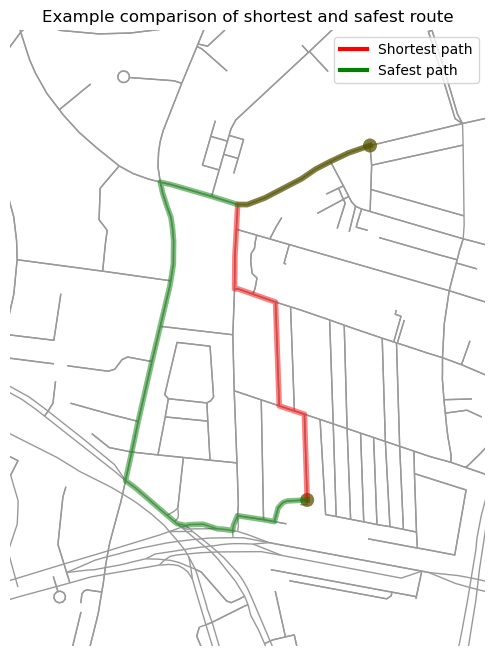

In [41]:
example = routes_sample[
    routes_sample["detour_m"].notna() &
    (routes_sample["detour_m"] > 0) &
    routes_sample["shortest_path"].notna() &
    routes_sample["safest_path"].notna()
].sample(1).iloc[0]

print("Address:", example["Adresse"])
print("School:", example["school_name"])
print("Shortest distance:", round(example["shortest_dist_m"], 1), "m")
print("Safest distance:", round(example["safest_dist_m"], 1), "m")
print("Detour:", round(example["detour_m"], 1), "m")
print("Detour ratio:", round(example["detour_ratio"], 2))

fig, ax = ox.plot_graph_route(
    G,
    example["shortest_path"],
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False
)

ox.plot_graph_route(
    G,
    example["safest_path"],
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    route_color="green",
    ax=ax,
    show=False,
    close=False
)

legend_elements = [
    Line2D([0], [0], color='red', lw=3, label='Shortest path'),
    Line2D([0], [0], color='green', lw=3, label='Safest path')
]

ax.legend(handles=legend_elements, loc='upper right')


route_nodes = example["shortest_path"] + example["safest_path"]

xs = [G.nodes[n]["x"] for n in route_nodes]
ys = [G.nodes[n]["y"] for n in route_nodes]

x_range = max(xs) - min(xs)
y_range = max(ys) - min(ys)

margin = max(x_range, y_range) * 0.3

ax.set_xlim(min(xs) - margin, max(xs) + margin)
ax.set_ylim(min(ys) - margin, max(ys) + margin)

plt.title("Example comparison of shortest and safest route")
plt.show()


### Distribution of shortest and safest route lengths (graphs)

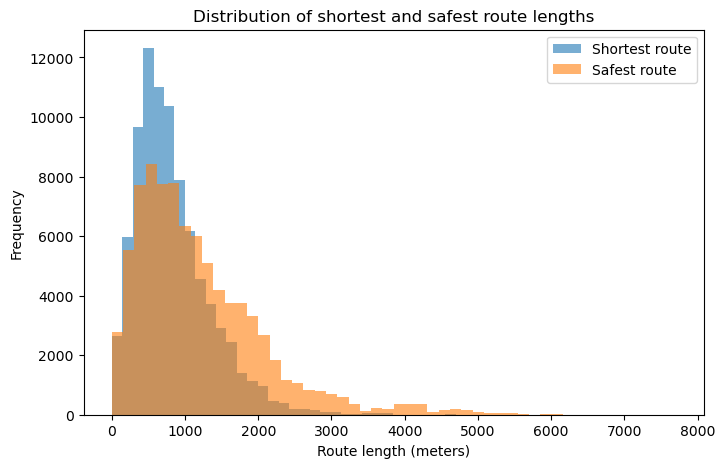

In [23]:
plt.figure(figsize=(8,5))

plt.hist(routes_sample["shortest_dist_m"], bins=50, alpha=0.6, label="Shortest route")
plt.hist(routes_sample["safest_dist_m"], bins=50, alpha=0.6, label="Safest route")

plt.xlabel("Route length (meters)")
plt.ylabel("Frequency")
plt.title("Distribution of shortest and safest route lengths")
plt.legend()

plt.show()

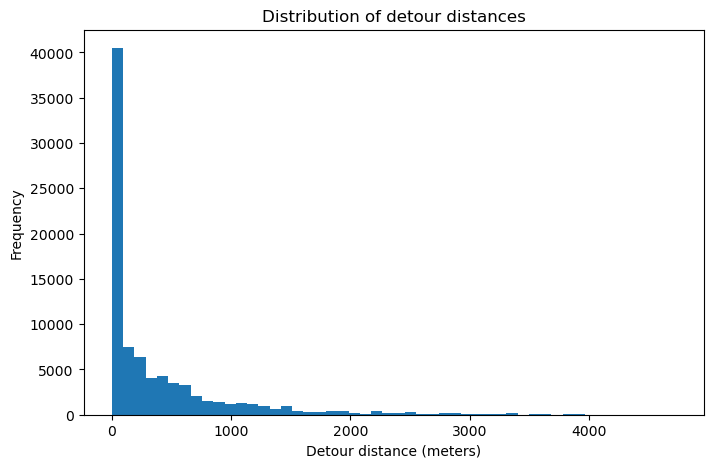

In [24]:
plt.figure(figsize=(8,5))
plt.hist(routes_sample["detour_m"], bins=50)

plt.xlabel("Detour distance (meters)")
plt.ylabel("Frequency")
plt.title("Distribution of detour distances")

plt.show()

## Check how often the shortest and safest routes are the same

Some addresses may already have a route that is both short and safe. 

Here we count how many sampled addresses have no detour at all.

In [ ]:
same_route_count = (routes_sample["detour_m"] == 0).sum()
different_route_count = (routes_sample["detour_m"] > 0).sum()

print("Same shortest and safest distance:", same_route_count)
print("Safest route is longer:", different_route_count)

In [ ]:
print((routes_sample["detour_m"] == 0).mean())

In [ ]:
results_export = routes_sample[
    [
        "Adresse",
        "district_code",
        "district_name_address",
        "address_id",
        "school_name",
        "district_name_school",
        "geometry",
        "school_x",
        "school_y",
        "euclidean_dist_m",
        "origin_node",
        "destination_node",
        "shortest_dist_m",
        "safest_cost",
        "safest_dist_m",
        "detour_m",
        "detour_ratio"
    ]
].copy()

results_export.to_file(
    "../data/processed/route_results.gpkg",
    layer="route_results",
    driver="GPKG"
)

print("Saved:", len(results_export), "rows")

In [ ]:
print(results_export.columns)